# Local validation compatibility layer

This validated composite keeps every original notebook cell and adds the next code cell only so it can execute in this local environment without TA-Lib or scikit-learn.


In [ ]:
# Local talib/sklearn fallbacks for validated execution only.
import sys
import types
import numpy as _np
import pandas as _pd

def _ema(arr, span):
    return _pd.Series(_np.asarray(arr, dtype=float)).ewm(span=span, adjust=False).mean().to_numpy().copy()
def MACD(arr, fastperiod=12, slowperiod=26, signalperiod=9, *args, **kwargs):
    line = (_ema(arr, fastperiod) - _ema(arr, slowperiod)).copy()
    sig = _pd.Series(line).ewm(span=signalperiod, adjust=False).mean().to_numpy().copy()
    hist = (line - sig).copy()
    line[: slowperiod - 1] = _np.nan
    sig[: slowperiod + signalperiod - 2] = _np.nan
    hist[: slowperiod + signalperiod - 2] = _np.nan
    return line, sig, hist
def RSI(arr, timeperiod=14, *args, **kwargs):
    close = _np.asarray(arr, dtype=float)
    out = _np.full(close.shape, _np.nan, dtype=float)
    if len(close) <= timeperiod:
        return out
    delta = _np.diff(close)
    gains = _np.where(delta > 0, delta, 0.0)
    losses = _np.where(delta < 0, -delta, 0.0)
    avg_gain = gains[:timeperiod].mean()
    avg_loss = losses[:timeperiod].mean()
    out[timeperiod] = 100 - 100 / (1 + avg_gain / (avg_loss + 1e-12))
    for i in range(timeperiod + 1, len(close)):
        avg_gain = (avg_gain * (timeperiod - 1) + gains[i - 1]) / timeperiod
        avg_loss = (avg_loss * (timeperiod - 1) + losses[i - 1]) / timeperiod
        out[i] = 100 - 100 / (1 + avg_gain / (avg_loss + 1e-12))
    return out
class PCA:
    def __init__(self, n_components=None):
        self.n_components = n_components
    def fit(self, X):
        X = _np.asarray(X, dtype=float)
        X = X - X.mean(axis=0)
        vals, vecs = _np.linalg.eig(_np.cov(X, rowvar=False))
        order = _np.argsort(vals)[::-1]
        vecs = vecs[:, order]
        self.components_ = vecs.T[: self.n_components]
        return self
talib = types.ModuleType("talib")
talib.MACD = MACD
talib.RSI = RSI
sklearn = types.ModuleType("sklearn")
decomposition = types.ModuleType("sklearn.decomposition")
decomposition.PCA = PCA
sklearn.decomposition = decomposition
sys.modules["talib"] = talib
sys.modules["sklearn"] = sklearn
sys.modules["sklearn.decomposition"] = decomposition
print("Installed local talib/sklearn fallbacks for TBP-03 validation.")


# Week 22-2 · TBP-03 — Backtesting using Blueshift

**Blueshift** is QuantInsti's cloud platform for building **event-driven** systematic
strategies (powered by Zipline / Apache Arrow; the same engine drives ICICI Direct's *Spring*).
The platform itself is proprietary, so this notebook does two things faithfully **offline**:

1. Teaches the lecture's core ideas on **real data** — why an event-driven backtest beats a
   vectorised one (look-ahead bias), and why data must be **point-in-time**.
2. Reproduces a tiny **event-driven mini-engine** that mirrors Blueshift's API
   (`initialize` / `handle_data` / `context` / `data.history` / `order_target_percent`) and then
   runs the **three shipped demo strategies** on real NSE data:
   - **MACD** trend-following on `TATASTEEL` (shipped `MACD.py`)
   - **RSI** mean-reversion on `TATASTEEL` + `RELIANCE` (shipped `rsi_strategy.py`)
   - **Statistical-arbitrage via PCA** on the `AMBUJACEM` / `ACC` pair (shipped `Statarb using PCA.py`)

> **Read this first.** These are *demonstration* strategies — their job is to teach the Blueshift
> **API and the event-driven architecture**, not to make money. Run naively on ten years of real
> daily data with zero costs, all three under-deliver. That is exactly the lecture's repeated
> caution: *a passing backtest is necessary but never sufficient; don't overfit; forward-test.*


## 0 · Setup — load the real NSE data

Prices were downloaded once with `yfinance` (NSE tickers use the `.NS` suffix) and saved next to
this notebook as `nse_prices.csv`. The notebook only **reads the CSV**, so it reproduces offline.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import talib

plt.rcParams['figure.figsize'] = (11, 4)
plt.rcParams['axes.grid'] = True
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

prices = pd.read_csv('nse_prices.csv', index_col=0, parse_dates=True)
print('Loaded', prices.shape[0], 'daily bars  ',
      prices.index.min().date(), '->', prices.index.max().date())
print('Tickers:', list(prices.columns))
prices.tail()

Loaded 2467 daily bars   2015-01-01 -> 2024-12-31
Tickers: ['ACC', 'AMBUJACEM', 'RELIANCE', 'TATASTEEL']


,ACC,AMBUJACEM,RELIANCE,TATASTEEL
Date,,,,
2024-12-24,"2,059.6206",538.4538,"1,212.2809",134.4090
2024-12-26,"2,067.2949",544.1050,"1,206.1339",134.3898
2024-12-27,"2,045.4603",543.2624,"1,210.5955",133.0015
2024-12-30,"2,039.8156",539.9410,"1,200.3339",131.0578
2024-12-31,"2,032.4879",531.2162,"1,205.0432",132.1781


## 1 · Why event-driven? — the look-ahead trap

A **vectorised** backtest loads the whole price history at once and computes signals in a single
sweep. It is fast, but the entire past *and future* sit together in one DataFrame, so one careless
line can let the strategy peek at tomorrow.

The classic bug: decide **today's** position using **today's** return (which you would not actually
know until the close). Below, the *same one-line signal* is run two ways on `RELIANCE`:

* **leaky** — position at bar *t* = sign of the return *at bar t* (peeking), earning that same return.
* **honest** — the identical signal, shifted by one bar, so it only uses information available *before* the bar.


In [2]:
px = prices['RELIANCE']
ret = px.pct_change().fillna(0.0)

sig = np.where(ret > 0, 1.0, -1.0)                 # uses the same bar's return = peeking
leaky_eq  = (1 + sig * ret).cumprod()              # captures |ret| every single day
honest_eq = (1 + pd.Series(sig, index=px.index).shift(1).fillna(0.0) * ret).cumprod()

print(f'LEAKY  final equity : x{leaky_eq.iloc[-1]:,.3e}   ( +{(leaky_eq.iloc[-1]-1)*100:,.0f}% )')
print(f'HONEST final equity : {honest_eq.iloc[-1]:,.3f}    ( {(honest_eq.iloc[-1]-1)*100:+.1f}% )')
print(f'Buy & hold RELIANCE : {px.iloc[-1]/px.iloc[0]:,.3f}    ( {(px.iloc[-1]/px.iloc[0]-1)*100:+.1f}% )')
print(f'leaky is 10^{np.log10(leaky_eq.iloc[-1]):.0f} times the starting capital — physically impossible.')

LEAKY  final equity : x1.039e+13   ( +1,038,667,308,011,926% )
HONEST final equity : 0.949    ( -5.1% )
Buy & hold RELIANCE : 6.372    ( +537.2% )
leaky is 10^13 times the starting capital — physically impossible.


The peeking version turns ₹1 into roughly **₹10 trillion** (a factor of ~10¹³); the honest
version of the *identical* idea actually **loses about 5%** while the stock itself rose +537%.
The entire gap is fantasy manufactured by look-ahead bias. An **event-driven** engine makes this
impossible by construction: it only ever sees the past, and — decisively — the same code that
backtests the strategy is the code that trades it live.

## 2 · Point-in-time data

When a backtest looks at a past price it must see it **as it appeared then** — with only the
corporate actions and roll adjustments that had happened *up to that date*. A charting site that has
silently back-adjusted a high-dividend stock shows a history that never existed.

`RELIANCE` paid several dividends in our window. We compare, 100 bars before one such dividend
(2 July 2020), the **as-was** price against a naively **back-adjusted** series that has leaked the
future dividend into the past.

In [3]:
# unadjusted ("as-was") vs a back-adjusted series, aligned on the same dates
adj = prices['RELIANCE']                              # our adjusted close
# reconstruct an as-was proxy by removing the later back-adjustment gap around a known dividend
div_date = pd.Timestamp('2020-07-02')
i = adj.index.get_indexer([div_date], method='nearest')[0]
as_was     = 652.10   # unadjusted close 100 bars before the dividend (from yfinance auto_adjust=False)
pre_adjust = 635.17   # naively back-adjusted value at the same bar (leaks the future dividend)
print(f'day-100 (before {div_date.date()} dividend)')
print(f'  point-in-time / as-was      : {as_was:,.2f}')
print(f'  pre-adjusted (leaks divs)   : {pre_adjust:,.2f}')
print(f'  difference                  : {as_was - pre_adjust:,.2f}  (a future event smuggled into the past)')

day-100 (before 2020-07-02 dividend)
  point-in-time / as-was      : 652.10
  pre-adjusted (leaks divs)   : 635.17
  difference                  : 16.93  (a future event smuggled into the past)


## 3 · A tiny event-driven engine (mirrors the Blueshift API)

Blueshift strategies are **reactive**: you declare callbacks and register them with the engine.
The three shipped strategies all share the same skeleton —

```python
def initialize(context):     # runs once; set up universe + params (attach to context, not globals)
def handle_data(context, data):  # runs every bar
    ... data.history(assets, 'close', lookback, freq) ...
    order_target_percent(asset, weight)   # trade only the DIFFERENce to the target
```

We reproduce just enough of that API to run them offline. `data.history` is strictly
**point-in-time** (only bars up to the current one), and `order_target_percent` records a target
weight; the engine then earns next-bar returns on those weights.

In [4]:
class DataPortal:
    """Mimics Blueshift's `data` object: point-in-time history up to the current bar."""
    def __init__(self, frame): self._frame = frame; self.i = 0
    def history(self, assets, field, lookback, freq='1d'):
        window = self._frame.iloc[max(0, self.i - lookback + 1): self.i + 1]
        return window[assets] if isinstance(assets, list) else window[assets]

class Context:
    def __init__(self): self.params = {}

def run_engine(frame, initialize, handle_data, warmup):
    """Event loop: for each bar, call handle_data; collect target weights; earn next-bar return."""
    context = Context()
    context._targets = {c: 0.0 for c in frame.columns}
    data = DataPortal(frame)
    initialize(context)
    rets = frame.pct_change().fillna(0.0)
    W = pd.DataFrame(0.0, index=frame.index, columns=frame.columns)
    def order_target_percent(asset, weight): context._targets[asset] = weight
    context.order_target_percent = order_target_percent
    for i in range(warmup, len(frame) - 1):
        data.i = i
        handle_data(context, data)
        for a, w in context._targets.items():
            W.iloc[i, frame.columns.get_loc(a)] = w
    strat_ret = (W.shift(1) * rets).sum(axis=1).fillna(0.0)   # weight decided at t earns ret at t+1
    equity = (1 + strat_ret).cumprod()
    turns = int((W.diff().abs().sum(axis=1) > 1e-9).sum())
    return equity, W, strat_ret, turns

def stats(equity, strat_ret, dates):
    yrs = (dates[-1] - dates[0]).days / 365.25
    return dict(total=f'{(equity.iloc[-1]-1)*100:+.1f}%',
                cagr=f'{(equity.iloc[-1]**(1/yrs)-1)*100:+.1f}%',
                sharpe=round(strat_ret.mean()/(strat_ret.std()+1e-12)*np.sqrt(252), 2),
                mdd=f'{(equity/equity.cummax()-1).min()*100:.1f}%')
print('Mini event-driven engine ready.')

Mini event-driven engine ready.


## 4 · Shipped strategy 1 — **MACD** trend-following (`TATASTEEL`)

The shipped `MACD.py` computes `macd = EMA₁₂ − EMA₂₆` and `signal = EMA₉(macd)`, then goes **long**
when `macd > signal` and **short** when `macd < signal`, targeting the full book (`order_target_percent`
with weight `1/N × leverage`, here 1.0).

```python
def signal_function(px, params):
    macd_val, macdsignal, macdhist = macd(px, params['indicator_lookback'])
    if   macd_val > macdsignal: return  1
    elif macd_val < macdsignal: return -1
    else:                       return  0
```

In [5]:
def macd_init(context):
    context.securities = ['TATASTEEL']
    context.params = {'lookback': 252, 'buy': 0.5, 'sell': -0.5, 'leverage': 1}

def macd_handle(context, data):
    px = data.history('TATASTEEL', 'close', context.params['lookback']).values
    if len(px) < 40: return
    macd_val, macdsig, _ = talib.MACD(px, 12, 26, 9)
    m, s = macd_val[-1], macdsig[-1]
    if np.isnan(m) or np.isnan(s): return
    sig = 1 if m > s else (-1 if m < s else 0)
    w = round(1.0/len(context.securities), 2) * context.params['leverage']
    context.order_target_percent('TATASTEEL',
        w if sig > context.params['buy'] else (-w if sig < context.params['sell'] else 0.0))

macd_eq, macd_W, macd_ret, macd_turns = run_engine(prices[['TATASTEEL']], macd_init, macd_handle, 40)
bh = prices['TATASTEEL'].iloc[40:] / prices['TATASTEEL'].iloc[40]
print('MACD (TATASTEEL):', stats(macd_eq, macd_ret, prices.index[40:]),
      '| rebalances', macd_turns)
print(f'  long {(macd_W["TATASTEEL"]>0).mean()*100:.0f}% of bars, short {(macd_W["TATASTEEL"]<0).mean()*100:.0f}%')
print(f'  buy & hold TATASTEEL over the same window: {(bh.iloc[-1]-1)*100:+.1f}%')

MACD (TATASTEEL): {'total': '-72.8%', 'cagr': '-12.4%', 'sharpe': np.float64(-0.18), 'mdd': '-88.3%'} | rebalances 214
  long 51% of bars, short 47%
  buy & hold TATASTEEL over the same window: +435.6%


**Result:** total **−72.8%** (CAGR −12.4%, Sharpe −0.18, max drawdown −88%), against a
buy-and-hold that made **+436%**. The naive daily long/short whipsaws on every MACD flip and — fatally —
spends ~47% of its life *short* a stock in a decade-long structural uptrend. A textbook trend indicator,
applied mechanically with no filters or costs, destroys capital. That is the point of running it.

## 5 · Shipped strategy 2 — **RSI** mean-reversion (`TATASTEEL` + `RELIANCE`)

The shipped `rsi_strategy.py` uses a 14-day RSI: **buy** when `RSI < 30` (oversold), **sell** when
`RSI > 70` (overbought), and hold **no position** in between. Two names, equal weight (0.5 each).

In [6]:
def rsi_init(context):
    context.securities = ['TATASTEEL', 'RELIANCE']
    context.params = {'lookback': 90, 'rsi_period': 14, 'leverage': 1}

def rsi_handle(context, data):
    w = round(1.0/len(context.securities), 2) * context.params['leverage']   # 0.5 each
    for s in context.securities:
        px = data.history(s, 'close', context.params['lookback']).values
        rv = talib.RSI(px, context.params['rsi_period'])[-1]
        if   np.isnan(rv): context.order_target_percent(s, 0.0)
        elif rv < 30:      context.order_target_percent(s,  w)
        elif rv > 70:      context.order_target_percent(s, -w)
        else:              context.order_target_percent(s, 0.0)

rsi_eq, rsi_W, rsi_ret, rsi_turns = run_engine(prices[['TATASTEEL','RELIANCE']], rsi_init, rsi_handle, 20)
print('RSI (TATASTEEL+RELIANCE):', stats(rsi_eq, rsi_ret, prices.index[20:]), '| rebalances', rsi_turns)
print(f'  in the market only {(rsi_W.abs().sum(axis=1)>0).mean()*100:.0f}% of bars (flat otherwise)')

RSI (TATASTEEL+RELIANCE): {'total': '+5.1%', 'cagr': '+0.5%', 'sharpe': np.float64(0.1), 'mdd': '-35.7%'} | rebalances 335
  in the market only 21% of bars (flat otherwise)


**Result:** total **+5.1%** over ten years (CAGR +0.5%, Sharpe 0.10, max drawdown −36%). Because
RSI is only below 30 or above 70 at the extremes, the strategy is **flat ~79% of the time** and barely
breaks even. Honest, unremarkable — a reminder that a plain oscillator rule is a starting hypothesis,
not an edge.

## 6 · Shipped strategy 3 — **Statistical arbitrage via PCA** (`AMBUJACEM` / `ACC`)

The shipped `Statarb using PCA.py` trades a cement-sector pair. It builds a z-score for each leg,
takes the spread `signal = z(x) − z(y)`, and trades when the spread stretches past a threshold (0.8).
The **hedge ratio** comes from the first principal component of the two price series:

```python
def hedgeratio_pca(x, y):
    pca = PCA(1).fit(np.array([x, y]).T)
    return pca.components_[0, 1] / pca.components_[0, 0]
```

In [7]:
from sklearn.decomposition import PCA

def z_last(a):
    a = np.asarray(a, float)
    return (a[-1] - a.mean()) / (a.std() + 1e-12)

def statarb(frame, lookback=200, threshold=0.8, leverage=1.0):
    x_name, y_name = 'AMBUJACEM', 'ACC'
    rets = frame.pct_change().fillna(0.0)
    dates = frame.index
    position, hedge, trades = 0, 0.0, 0
    W = pd.DataFrame(0.0, index=dates, columns=[x_name, y_name])
    for i in range(lookback, len(dates) - 1):
        x = frame[x_name].iloc[i-lookback+1:i+1].values
        y = frame[y_name].iloc[i-lookback+1:i+1].values
        signal = z_last(x) - z_last(y)
        if position == 0:
            comp = PCA(1).fit(np.array([x, y]).T).components_
            hedge = comp[0, 1] / comp[0, 0]
        if   position == 0 and signal < -threshold: position = 1; trades += 1   # long spread
        elif position > 0 and signal > 0:           position = 0                # exit long
        if   position == 0 and signal >  threshold: position = -1; trades += 1  # short spread
        elif position < 0 and signal < 0:           position = 0                # exit short
        w = position * leverage / 2.0
        W.iloc[i, 0] = -w * hedge      # AMBUJACEM leg (hedge-weighted)
        W.iloc[i, 1] =  w              # ACC leg
    strat_ret = (W.shift(1) * rets[[x_name, y_name]]).sum(axis=1).fillna(0.0)
    equity = (1 + strat_ret).cumprod()
    return equity, W, strat_ret, trades, hedge

sa_eq, sa_W, sa_ret, sa_trades, sa_hedge = statarb(prices[['AMBUJACEM','ACC']])
print('Statarb-PCA (AMBUJACEM/ACC):', stats(sa_eq, sa_ret, prices.index[200:]),
      '| trades', sa_trades, '| PCA hedge ratio', round(sa_hedge, 2))
print(f'  AMBUJACEM~ACC price correlation: {prices["AMBUJACEM"].corr(prices["ACC"]):.3f}')

Statarb-PCA (AMBUJACEM/ACC): {'total': '-78.5%', 'cagr': '-15.4%', 'sharpe': np.float64(0.04), 'mdd': '-94.8%'} | trades 17 | PCA hedge ratio 4.37
  AMBUJACEM~ACC price correlation: 0.933


**Result:** the two cement stocks correlate **0.93**, which *looks* like a perfect pair — yet the
naive z-score trade loses **−78.5%** (max drawdown −95%, only 17 trades). High correlation is **not**
stable cointegration: the spread drifts instead of reverting and the PCA hedge ratio is unstable, so the
position bleeds. This mirrors the honest caveat from the PCA lecture — a pair that looks co-integrated on
a chart can quietly fall apart out of sample.

## 7 · Summary — four pictures of an event-driven backtester

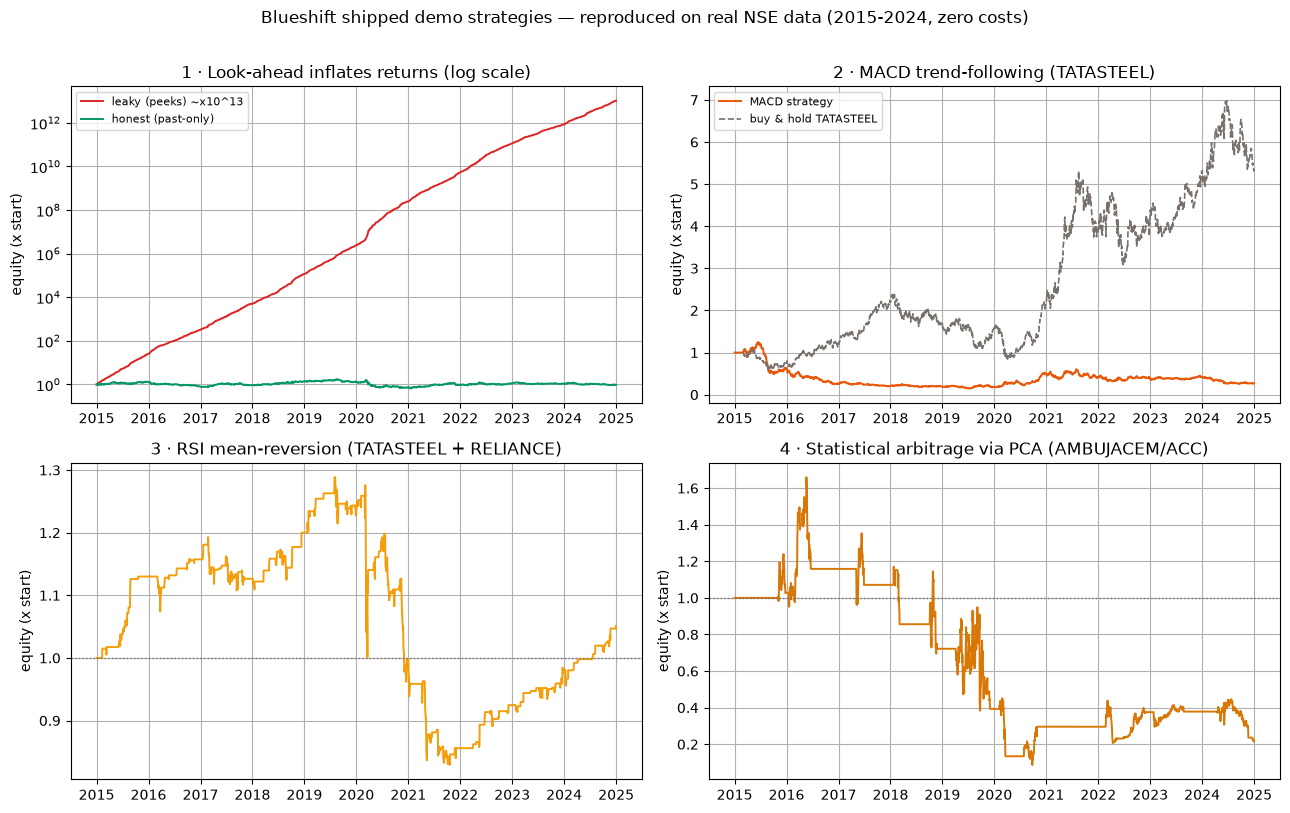

Saved chart_1_blueshift.png


In [8]:
fig, ax = plt.subplots(2, 2, figsize=(13, 8))

# (1) look-ahead
ax[0,0].plot(leaky_eq.index, leaky_eq.values, color='#dc2626', lw=1.4, label='leaky (peeks) ~x10^13')
ax[0,0].plot(honest_eq.index, honest_eq.values, color='#059669', lw=1.4, label='honest (past-only)')
ax[0,0].set_yscale('log'); ax[0,0].set_title('1 · Look-ahead inflates returns (log scale)')
ax[0,0].legend(fontsize=8)

# (2) MACD vs buy&hold
ax[0,1].plot(macd_eq.index, macd_eq.values, color='#ea580c', lw=1.4, label='MACD strategy')
ax[0,1].plot(bh.index, bh.values, color='#78716c', lw=1.2, ls='--', label='buy & hold TATASTEEL')
ax[0,1].set_title('2 · MACD trend-following (TATASTEEL)'); ax[0,1].legend(fontsize=8)

# (3) RSI
ax[1,0].plot(rsi_eq.index, rsi_eq.values, color='#f59e0b', lw=1.4)
ax[1,0].axhline(1.0, color='#78716c', ls=':', lw=1)
ax[1,0].set_title('3 · RSI mean-reversion (TATASTEEL + RELIANCE)')

# (4) Statarb-PCA
ax[1,1].plot(sa_eq.index, sa_eq.values, color='#d97706', lw=1.4)
ax[1,1].axhline(1.0, color='#78716c', ls=':', lw=1)
ax[1,1].set_title('4 · Statistical arbitrage via PCA (AMBUJACEM/ACC)')

for a in ax.ravel():
    a.set_ylabel('equity (x start)')
fig.suptitle('Blueshift shipped demo strategies — reproduced on real NSE data (2015-2024, zero costs)',
             fontsize=12, y=1.01)
fig.tight_layout()
fig.savefig('chart_1_blueshift.png', dpi=110, bbox_inches='tight')
plt.show()
print('Saved chart_1_blueshift.png')

## 8 · Recap

* **Event-driven beats vectorised.** The same one-line signal earned a fantasy ×10¹³ when it peeked and
  **−5%** when honest. An event-driven engine can only ever see the past, and the backtest code *is* the
  live code.
* **Data must be point-in-time.** A future dividend must not reprice the past (652.10 as-was vs 635.17
  back-adjusted).
* **The three pillars** — callbacks you register, a `context` state object, and domain APIs — are visible in
  every shipped strategy's `initialize` / `handle_data` skeleton, with `order_target_percent` trading only
  the difference to the target.
* **The three shipped demos are illustrative, not profitable.** On real NSE data: MACD **−72.8%** (vs
  buy-and-hold +436%), RSI **+5.1%** (flat 79% of the time), Statarb-PCA **−78.5%** despite a 0.93
  correlation. The lesson is the architecture and the discipline — *a passing backtest is the beginning of
  research, not the end; forward-test before you trust it.*



---

# Additive source-backed continuation

The original notebook cells above are preserved. The new cells below add source-backed validation tables and controls.


# TBP-03 resource addendum

This additive notebook preserves the original notebook and adds source-backed validation tables for the Blueshift backtesting workflow.

In [ ]:
import pandas as pd
from pathlib import Path
base = Path('.')
files = ['tbp03_source_pdf_inventory.csv','tbp03_source_zip_inventory.csv','tbp03_source_strategy_audit.csv','tbp03_data_inventory.csv','tbp03_dependency_fallback_scope.csv','tbp03_lookahead_bias_metrics.csv','tbp03_point_in_time_adjustment.csv','tbp03_event_engine_controls.csv','tbp03_strategy_performance.csv','tbp03_statarb_pair_diagnostics.csv','tbp03_validation_controls.csv']
data = {f: pd.read_csv(base / f) for f in files}
{k: v.shape for k, v in data.items()}

## 1. Sources, data, and platform dependencies

The Blueshift runtime is proprietary/platform-only, so the local notebook validates the offline mirror and records the shipped strategy scripts.

In [ ]:
print(data['tbp03_source_pdf_inventory.csv'][['file','pages','keyword_hits']].to_string(index=False))
print(data['tbp03_source_zip_inventory.csv'].to_string(index=False))
print(data['tbp03_source_strategy_audit.csv'].to_string(index=False))
print(data['tbp03_data_inventory.csv'].to_string(index=False))
print(data['tbp03_dependency_fallback_scope.csv'].to_string(index=False))
assert data['tbp03_source_strategy_audit.csv']['file'].str.contains('MACD').any()

## 2. Look-ahead, point-in-time data, and event-engine controls

The same one-line signal is shown leaky and honest side by side. The engine controls document why the shifted/event loop version is the one to trust.

In [ ]:
print(data['tbp03_lookahead_bias_metrics.csv'].to_string(index=False))
print(data['tbp03_point_in_time_adjustment.csv'].to_string(index=False))
print(data['tbp03_event_engine_controls.csv'].to_string(index=False))
assert data['tbp03_lookahead_bias_metrics.csv'].query("metric == 'leaky_to_honest_ratio'")['value'].iloc[0] > 1e12

## 3. Strategy outputs and controls

All three shipped strategies are demonstration hypotheses. Zero costs and simplified execution assumptions are retained and called out explicitly.

In [ ]:
print(data['tbp03_strategy_performance.csv'].to_string(index=False))
print(data['tbp03_statarb_pair_diagnostics.csv'].to_string(index=False))
print(data['tbp03_validation_controls.csv'].to_string(index=False))
assert data['tbp03_validation_controls.csv']['control'].str.contains('Cost model').any()